In [1]:
import os
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
import tensorflow.keras.backend as K

# 1: load the chronologically partitioned and scaled datasets 
data_dir = 'Model_Ready_Data_Agus1'

df_train = pd.read_csv(os.path.join(data_dir, 'Train.csv'), index_col='Time', parse_dates=True, dayfirst=True)
df_val = pd.read_csv(os.path.join(data_dir, 'Validation.csv'), index_col='Time', parse_dates=True, dayfirst=True)
df_calib = pd.read_csv(os.path.join(data_dir, 'Calibration.csv'), index_col='Time', parse_dates=True, dayfirst=True)
df_test = pd.read_csv(os.path.join(data_dir, 'Test.csv'), index_col='Time', parse_dates=True, dayfirst=True)

target_col_name = 'Total_Power' 
target_idx = df_train.columns.get_loc(target_col_name)

# 2: define the sliding window function to generate temporal sequences
def create_sequences(data, target_index, lookback, horizon=1):
    X, y = [], []
    data_array = data.values 
    for i in range(len(data_array) - lookback - horizon + 1):
        X_seq = data_array[i : (i + lookback), :]
        y_target = data_array[i + lookback + horizon - 1, target_index]
        X.append(X_seq)
        y.append(y_target)
    return np.array(X), np.array(y)

LOOKBACK = 96  # 24 hours of memory
HORIZON = 1    # 15 mins into the future

X_train, y_train = create_sequences(df_train, target_idx, LOOKBACK, HORIZON)
X_val, y_val = create_sequences(df_val, target_idx, LOOKBACK, HORIZON)
X_calib, y_calib = create_sequences(df_calib, target_idx, LOOKBACK, HORIZON)
X_test, y_test = create_sequences(df_test, target_idx, LOOKBACK, HORIZON)

# #: configure the custom dual-quantile pinball loss function 
QUANTILES = [0.05, 0.95]

def pinball_loss(y_true, y_pred):

    y_true_expanded = tf.expand_dims(y_true, axis=-1)
 
    q_lower = QUANTILES[0]
    err_lower = y_true_expanded - y_pred[:, 0:1]
    loss_lower = K.maximum(q_lower * err_lower, (q_lower - 1) * err_lower)

    q_upper = QUANTILES[1]
    err_upper = y_true_expanded - y_pred[:, 1:2]
    loss_upper = K.maximum(q_upper * err_upper, (q_upper - 1) * err_upper)
    
    return K.mean(loss_lower + loss_upper)
    
# 4: construct the 2-stacked LSTM architecture 
n_timesteps = X_train.shape[1] 
n_features = X_train.shape[2]

model = Sequential()
model.add(Input(shape=(n_timesteps, n_features)))

model.add(LSTM(units=64, return_sequences=True))
model.add(Dropout(0.2)) 

model.add(LSTM(units=32, return_sequences=False))
model.add(Dropout(0.2))

# 5: compile the model with two output neurons for the upper and lower prediction bounds
model.add(Dense(units=2))
model.compile(optimizer='adam', loss=pinball_loss)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape          ┃      Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━┩
│ lstm (LSTM)                   │ (None, 96, 128)       │       70,144 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ dropout (Dropout)             │ (None, 96, 128)       │            0 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ lstm_1 (LSTM)                 │ (None, 96, 64)        │       49,408 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ dropout_1 (Dropout)           │ (None, 96, 64)        │            0 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ lstm_2 (LSTM)                 │ (None, 32)            │       12,416 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ dropout_2 (Dropout)           │ (None, 32)            │            0 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ dense (Dense)                 │ (None, 2)             │           66 │
└───────────────────────────────┴───────────────────────┴──────────────┘

 Total params: 132,034 (515.76 KB)

 Trainable params: 132,034 (515.76 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
982/982 ━━━━━━━━━━━━━━━━━━━━ 191s 187ms/step - loss: 0.0441 - val_loss: 0.0348
Epoch 2/50
982/982 ━━━━━━━━━━━━━━━━━━━━ 222s 208ms/step - loss: 0.0352 - val_loss: 0.0331
Epoch 3/50
982/982 ━━━━━━━━━━━━━━━━━━━━ 208s 212ms/step - loss: 0.0332 - val_loss: 0.0313
Epoch 4/50
982/982 ━━━━━━━━━━━━━━━━━━━━ 211s 215ms/step - loss: 0.0316 - val_loss: 0.0282
Epoch 5/50
982/982 ━━━━━━━━━━━━━━━━━━━━ 204s 208ms/step - loss: 0.0309 - val_loss: 0.0281
Epoch 6/50
982/982 ━━━━━━━━━━━━━━━━━━━━ 259s 205ms/step - loss: 0.0304 - val_loss: 0.0287
Epoch 7/50
982/982 ━━━━━━━━━━━━━━━━━━━━ 192s 196ms/step - loss: 0.0300 - val_loss: 0.0270
Epoch 8/50
982/982 ━━━━━━━━━━━━━━━━━━━━ 209s 203ms/step - loss: 0.0296 - val_loss: 0.0266
Epoch 9/50
982/982 ━━━━━━━━━━━━━━━━━━━━ 196s 199ms/step - loss: 0.0296 - val_loss: 0.0258
Epoch 10/50
982/982 ━━━━━━━━━━━━━━━━━━━━ 196s 199ms/step - loss: 0.0291 - val_loss: 0.0269
Epoch 11/50
982/982 ━━━━━━━━━━━━━━━━━━━━ 171s 174ms/step - loss: 0.0291 - val_loss: 0.0264
Epoch 12

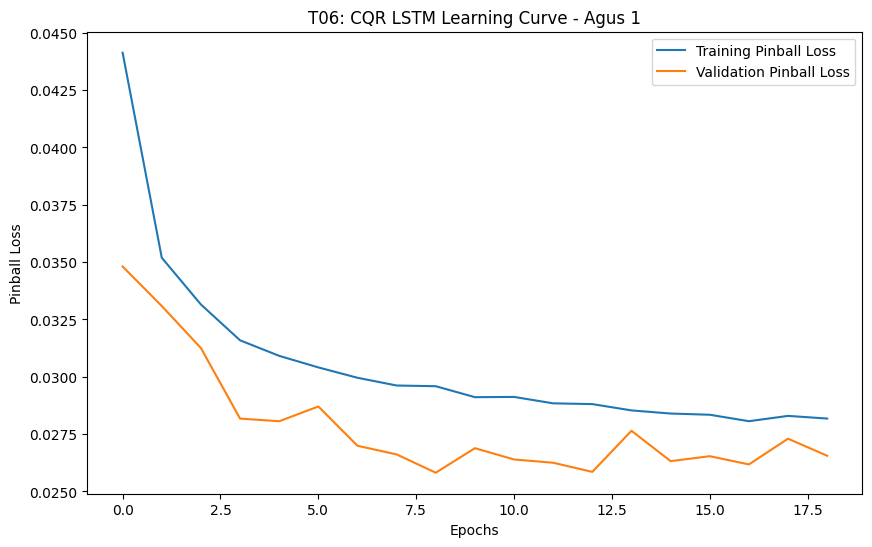

In [2]:
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# 1: configure early stopping mechanism to prevent overfitting 
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# 2: execute model training using the custom pinball loss funtion
history = model.fit(
    X_train, y_train,
    epochs=50,          
    batch_size=32,      
    validation_data=(X_val, y_val), 
    callbacks=[early_stop],         
    verbose=1           
)

# 3: visualize the learning curve to verify convergence
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Pinball Loss')
plt.plot(history.history['val_loss'], label='Validation Pinball Loss')
plt.title('T06: CQR LSTM Learning Curve - Agus 1')
plt.xlabel('Epochs')
plt.ylabel('Pinball Loss')
plt.legend()
plt.show()

244/244 ━━━━━━━━━━━━━━━━━━━━ 21s 82ms/step
244/244 ━━━━━━━━━━━━━━━━━━━━ 18s 73ms/step
--- RESULTS FOR T06 ---
RMSE: 3.4041 MW
R-Squared: 0.9082
PICP: 91.63% (Target: 90%)
PINAW: 0.1187
Winkler Index: 14.1351


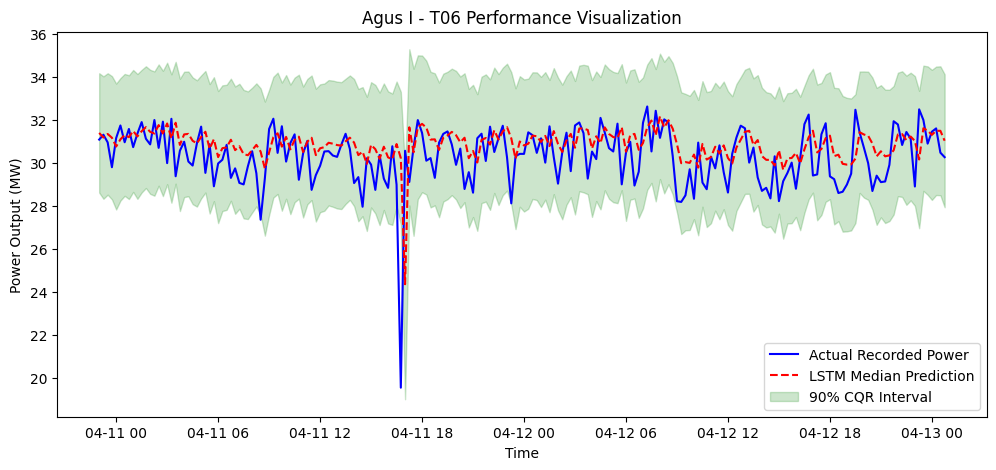

In [3]:
import os
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import RobustScaler

# --- 1: CONFIGURATION ---
trial_id = "T06"  # Update this for each trial (e.g., T02, T03)
output_dir = os.path.join('Optimization_Results', trial_id)
alpha = 0.10 
os.makedirs(output_dir, exist_ok=True)

# --- 2: RECONSTRUCT SCALER (Essential for MW Conversion) ---
# Load the original processed dataset to fit the scaler strictly on the training set
original_df = pd.read_csv('Processed_Agus1_Dataset.csv', index_col='Time', parse_dates=True, dayfirst=True)
features = original_df.columns.tolist()
train_end = int(len(original_df) * 0.60)

scaler = RobustScaler()
scaler.fit(original_df.iloc[:train_end][features])

# --- 3: EXECUTE INFERENCE (PHASE 2) ---
# Ensure 'model', 'X_calib', and 'X_test' are already defined in your workspace
calib_preds = model.predict(X_calib)
test_preds = model.predict(X_test)

# --- 4: UNSCALING FUNCTION ---
def unscale_cqr(preds, actuals):
    dummy_act = np.zeros((len(actuals), len(features)))
    dummy_lower = np.zeros((len(preds), len(features)))
    dummy_upper = np.zeros((len(preds), len(features)))

    dummy_act[:, 0] = actuals
    dummy_lower[:, 0] = preds[:, 0] 
    dummy_upper[:, 0] = preds[:, 1] 

    real_act = scaler.inverse_transform(dummy_act)[:, 0]
    real_low = scaler.inverse_transform(dummy_lower)[:, 0]
    real_up = scaler.inverse_transform(dummy_upper)[:, 0]
    
    return real_act, real_low, real_up

# Convert normalized predictions back into real Megawatts (MW)
real_y_calib, real_low_calib, real_up_calib = unscale_cqr(calib_preds, y_calib)
real_y_test, real_low_test, real_up_test = unscale_cqr(test_preds, y_test)

# --- 5: CONFORMAL CALIBRATION (PHASE 3) ---
scores = np.maximum(real_low_calib - real_y_calib, real_y_calib - real_up_calib)
n_calib = len(real_y_calib)
q_level = min(math.ceil((n_calib + 1) * (1 - alpha)) / n_calib, 1.0)
q_hat = np.quantile(scores, q_level, method='higher')

# --- 6: EVALUATION DATASET PREPARATION ---
# Use the existing index from your test dataframe
dates_test = df_test.index[LOOKBACK + HORIZON - 1:]
df_results = pd.DataFrame({'Actual_MW': real_y_test}, index=dates_test)

# Apply calibrated adjustment and physical constraints (Agus I)
# We use np.clip with explicit min/max to avoid the ValueError
df_results['Physics_Lower_MW'] = np.clip(real_low_test - q_hat, a_min=5.04, a_max=None)
df_results['Physics_Upper_MW'] = np.clip(real_up_test + q_hat, a_min=None, a_max=80.0)

# For the point prediction, we clip both ends to ensure it stays within physical limits
point_preds = (real_low_test + real_up_test) / 2
df_results['Point_Prediction_MW'] = np.clip(point_preds, a_min=5.04, a_max=80.0)

# --- 7: METRICS CALCULATION (PHASE 4) ---
y_true = df_results['Actual_MW'].values
y_pred = df_results['Point_Prediction_MW'].values
lower = df_results['Physics_Lower_MW'].values
upper = df_results['Physics_Upper_MW'].values

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)
picp = np.mean((y_true >= lower) & (y_true <= upper)) * 100
pinaw = np.mean(upper - lower) / (np.max(y_true) - np.min(y_true))

# Winkler Index
widths = upper - lower
penalties = np.zeros_like(y_true)
penalties[y_true < lower] = (2 / alpha) * (lower[y_true < lower] - y_true[y_true < lower])
penalties[y_true > upper] = (2 / alpha) * (y_true[y_true > upper] - upper[y_true > upper])
winkler = np.mean(widths + penalties)

# --- 8: OUTPUTS ---
print(f"--- RESULTS FOR {trial_id} ---")
print(f"RMSE: {rmse:.4f} MW")
print(f"R-Squared: {r2:.4f}")
print(f"PICP: {picp:.2f}% (Target: 90%)")
print(f"PINAW: {pinaw:.4f}")
print(f"Winkler Index: {winkler:.4f}")

# Save results and plot to the trial folder
df_results.to_csv(os.path.join(output_dir, f'{trial_id}_Final_Results.csv'))

plt.figure(figsize=(12, 5))
plt.plot(df_results.index[:200], y_true[:200], label='Actual Recorded Power', color='blue')
plt.plot(df_results.index[:200], y_pred[:200], label='LSTM Median Prediction', color='red', linestyle='--')
plt.fill_between(df_results.index[:200], lower[:200], upper[:200], color='green', alpha=0.2, label='90% CQR Interval')
plt.title(f"Agus I - {trial_id} Performance Visualization")
plt.xlabel("Time")
plt.ylabel("Power Output (MW)")
plt.legend(loc='lower right')
plt.savefig(os.path.join(output_dir, f'{trial_id}_Plot.png'), dpi=300)
plt.show()